In [1]:
from google.colab import files
uploaded = files.upload()

Saving iris.data to iris.data


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.neighbors import KNeighborsClassifier
import sklearn.metrics as metrics
from sklearn.model_selection import train_test_split, RepeatedKFold, cross_validate


In [5]:
import pandas as pd
columns = ['sepal-length','sepal-width','petal-length','petal-width','class']
iris = pd.read_csv('iris.data',names=columns)

X = iris[['sepal-length','sepal-width','petal-length','petal-width']]
X = X.values
X = (X - X.min(axis=0))/(X.max(axis=0) - X.min(axis=0))

y = iris[['class']]
y = y.values.ravel()


In [17]:
nn = 30 # valores de k (KNN) desde 1 hasta nn
aleatorizaciones = 50 # aleatorizaciones
k_folds = 5

In [18]:
k = np.zeros(nn)
k_training_acc = np.zeros(nn)
k_testing_acc = np.zeros(nn)

for i in range(1,nn+1):
  k[i-1] = i
  rkf = RepeatedKFold(n_splits=k_folds, n_repeats=aleatorizaciones, random_state=0)
  model = KNeighborsClassifier(n_neighbors=i, algorithm='brute')

  scores = cross_validate(model, X, y, cv=rkf, scoring='accuracy', return_train_score=True)
  k_training_acc[i-1] = scores['train_score'].mean()
  k_testing_acc[i-1] = scores['test_score'].mean()


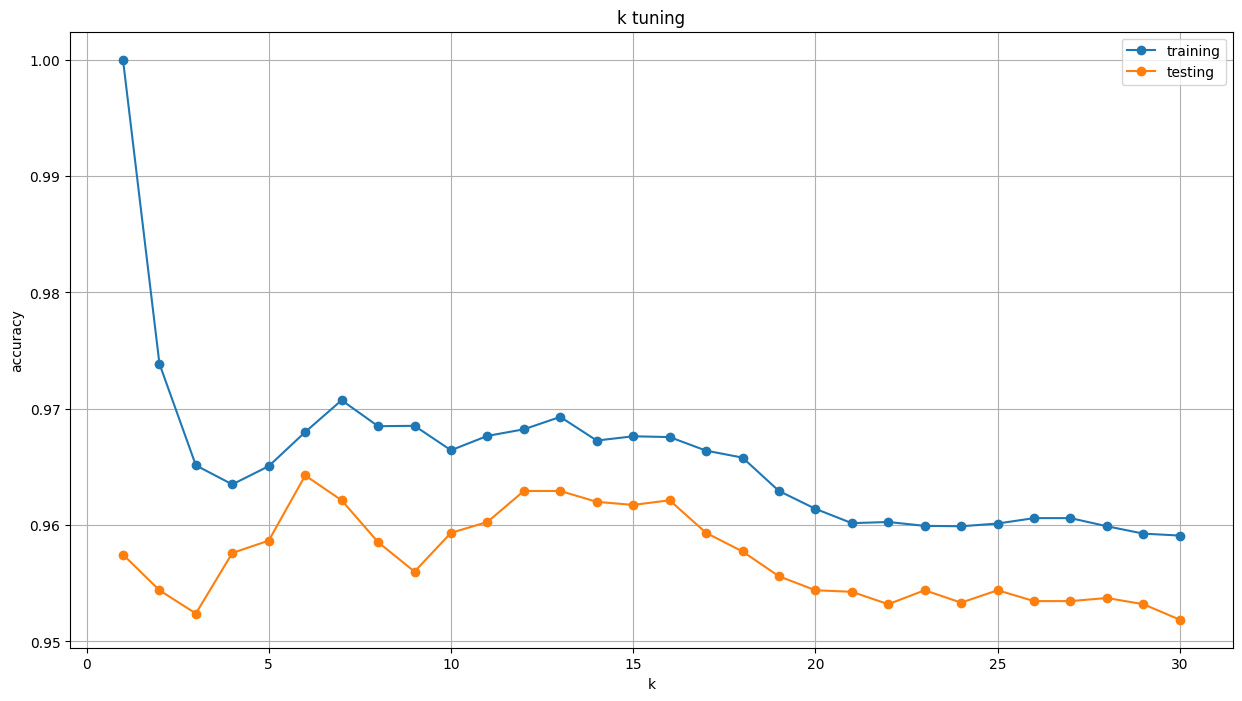

In [19]:
plt.figure(figsize=(15,8))
plt.plot(k,k_training_acc, '-o', label='training')
plt.plot(k,k_testing_acc,'-o', label='testing')

plt.legend()
plt.xlabel('k')
plt.ylabel('accuracy')
plt.grid()
plt.title('k tuning')
plt.show()

In [20]:

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=0)
knn_classifier = KNeighborsClassifier(n_neighbors=6,algorithm='brute')
knn_classifier.fit(X_train, y_train)

y_train_hat = knn_classifier.predict(X_train)
y_test_hat = knn_classifier.predict(X_test)

print(metrics.accuracy_score(y_test,y_test_hat))
print(metrics.confusion_matrix(y_test,y_test_hat))
print(metrics.f1_score(y_test, y_test_hat, average=None))
print(metrics.classification_report(y_test, y_test_hat))


1.0
[[11  0  0]
 [ 0 13  0]
 [ 0  0  6]]
[1. 1. 1.]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        11
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00         6

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [22]:
model = KNeighborsClassifier(n_neighbors=6,algorithm='brute')
model.fit(X, y)

KNeighborsClassifier(algorithm='brute', n_neighbors=6)

In [23]:
import pickle
filename = 'knn_6_iris.pkl'
pickle.dump(model, open(filename, 'wb'))